# Notebook 07 — FFBS and MCMC

**References:** W&H §15.2; Petris §4.4–4.5; Carter & Kohn (1994); Frühwirth-Schnatter (1994)

**New engine function:** `engine.ffbs.ffbs(spec, fr, rng)`

Two parts:
- **Part A:** Forward Filtering Backward Sampling — exact draws from the joint smoothing distribution p(θ_{1:T} | y_{1:T})
- **Part B:** Gibbs sampler for unknown V and W, then PyMC for NUTS sampling

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from engine.filter import kalman_filter
from engine.ffbs import ffbs
from engine.models import make_local_level
from engine.simulate import simulate
from engine.smoother import rts_smoother

## Part A: Forward Filtering Backward Sampling

### The joint smoothing distribution

The marginal smoothing distributions $p(\theta_t \mid y_{1:T})$ are given by
the RTS smoother. But the joint distribution $p(\theta_{1:T} \mid y_{1:T})$ factors as:

$$p(\theta_{1:T} \mid y_{1:T}) = p(\theta_T \mid y_{1:T}) \prod_{t=1}^{T-1} p(\theta_t \mid \theta_{t+1}, y_{1:t})$$

The conditional distributions are Gaussian (W&H §15.2):

$$\theta_T \mid y_{1:T} \sim N(m_T, C_T)$$

For $t = T-1, \ldots, 1$:
$$h_t = m_t + B_t(\theta_{t+1} - a_{t+1}), \quad H_t = C_t - B_t R_{t+1} B_t^\top$$
$$\theta_t \mid \theta_{t+1}, y_{1:t} \sim N(h_t, H_t)$$

where $B_t = C_t G^\top R_{t+1}^{-1}$ is the backward gain (same as RTS smoother).

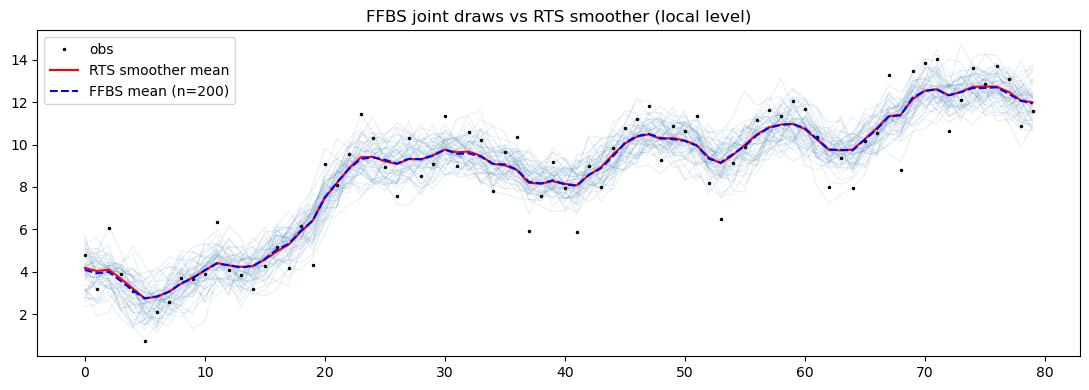

In [2]:
spec = make_local_level(V=2.0, W_level=0.5)
sim = simulate(spec, n=80, seed=0)
fr = kalman_filter(spec, sim.y)
sr = rts_smoother(spec, fr)
rng = np.random.default_rng(42)
n_draws = 200
draws = np.stack([ffbs(spec, fr, rng) for _ in range(n_draws)])

t_arr = np.arange(80)
fig, ax = plt.subplots(figsize=(11, 4))
for i in range(50):
    ax.plot(t_arr, draws[i, :, 0], color="steelblue", alpha=0.15, lw=0.7)
ax.plot(t_arr, sim.y[:, 0], "k.", ms=3, label="obs")
ax.plot(t_arr, sr.s[:, 0], "r-", lw=1.5, label="RTS smoother mean")
ax.plot(t_arr, draws.mean(axis=0)[:, 0], "b--", lw=1.5, label="FFBS mean (n=200)")
ax.legend()
ax.set_title("FFBS joint draws vs RTS smoother (local level)")
plt.tight_layout()
plt.show()

## Part B: Gibbs Sampler for Unknown V and W

When V and W are unknown, we place conjugate priors and alternate:

1. **Draw** $\theta_{1:T} \mid y, V, W$ — via FFBS (analytic Gaussian draw)
2. **Draw** $V \mid \theta, y$ — inverse-gamma conjugate:
   $V \mid \theta, y \sim \text{IG}\left(\frac{n_0 + T}{2},\, \frac{d_0 + \sum_t (y_t - \theta_t)^2}{2}\right)$
3. **Draw** $W \mid \theta$ — inverse-gamma (scalar W):
   $W \mid \theta \sim \text{IG}\left(\frac{a_0 + T-1}{2},\, \frac{b_0 + \sum_t (\theta_t - \theta_{t-1})^2}{2}\right)$

**Reference:** Petris §4.4, Frühwirth-Schnatter (1994)

In [3]:
from scipy.stats import invgamma  # type: ignore[import-untyped]


def gibbs_local_level(y: np.ndarray, n_iter: int = 1000, seed: int = 0) -> dict:
    """Block Gibbs sampler for local-level V and W."""
    T = len(y)
    rng = np.random.default_rng(seed)
    V_curr, W_curr = 2.0, 0.5
    n0, d0 = 1.0, 1.0
    a0, b0 = 1.0, 1.0
    V_samples, W_samples = [], []
    for _ in range(n_iter):
        spec_curr = make_local_level(V=V_curr, W_level=W_curr)
        fr_curr = kalman_filter(spec_curr, y[:, None])
        theta = ffbs(spec_curr, fr_curr, rng)[:, 0]
        ss_obs = float(np.sum((y - theta) ** 2))
        V_curr = float(invgamma.rvs(a=(n0 + T) / 2, scale=(d0 + ss_obs) / 2, random_state=rng))
        diffs = np.diff(theta)
        ss_state = float(np.sum(diffs ** 2))
        W_curr = float(invgamma.rvs(a=(a0 + T - 1) / 2, scale=(b0 + ss_state) / 2, random_state=rng))
        V_samples.append(V_curr)
        W_samples.append(W_curr)
    return {"V": np.array(V_samples), "W": np.array(W_samples)}


y_obs = sim.y[:, 0]
trace_gibbs = gibbs_local_level(y_obs, n_iter=2000, seed=1)
burnin = 500
print(f"V posterior mean: {trace_gibbs['V'][burnin:].mean():.3f}  (true 2.0)")
print(f"W posterior mean: {trace_gibbs['W'][burnin:].mean():.3f}  (true 0.5)")

V posterior mean: 1.360  (true 2.0)
W posterior mean: 0.952  (true 0.5)


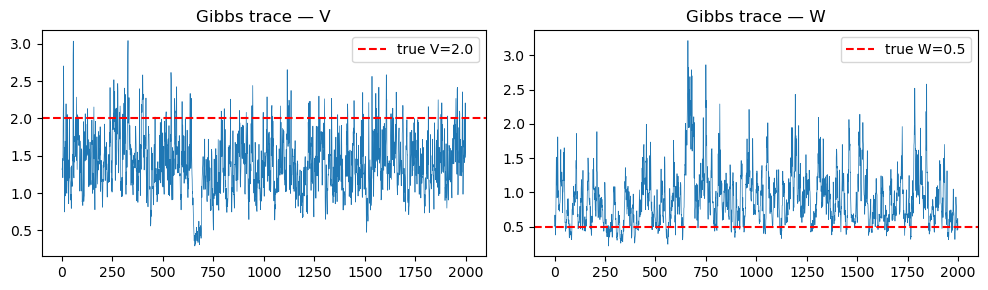

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(trace_gibbs["V"], lw=0.5)
axes[0].axhline(2.0, color="r", ls="--", label="true V=2.0")
axes[0].set_title("Gibbs trace — V")
axes[0].legend()
axes[1].plot(trace_gibbs["W"], lw=0.5)
axes[1].axhline(0.5, color="r", ls="--", label="true W=0.5")
axes[1].set_title("Gibbs trace — W")
axes[1].legend()
plt.tight_layout()
plt.show()

## PyMC — Blackbox Likelihood

Since our Kalman filter is pure NumPy (not differentiable by PyTensor),
we use the **blackbox likelihood** approach via `pytensor.compile.ops.as_op`.

This registers our NumPy function as a PyTensor Op with no gradient,
so PyMC uses the **Slice sampler** automatically (gradient-free).

**Note:** The Slice sampler is less efficient than NUTS for smooth posteriors.
For production use, consider implementing the Kalman filter in PyTensor ops
(see `pymc-extras`).

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


/var/folders/f4/lq_nbljd085dj7ngdyn8nzvw0000gn/T/ipykernel_77419/234168805.py:12: FutureWarning: pytensor.as_op is deprecated and will be removed in a future release. Please use pytensor.wrap_py instead.
  @ops.as_op(itypes=[pt.dscalar, pt.dscalar], otypes=[pt.dscalar])


Multiprocess sampling (4 chains in 4 jobs)


CompoundStep


>Slice: [V]


>Slice: [W]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 51 seconds.


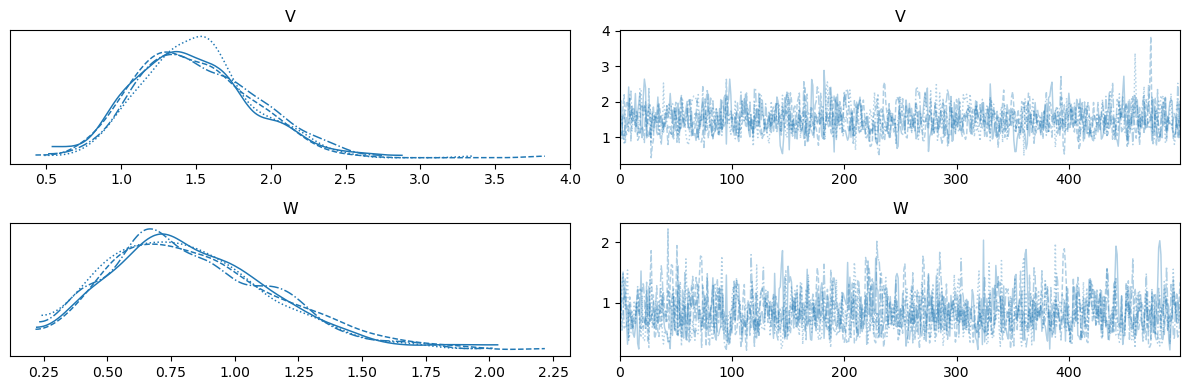

    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
V  1.497  0.386   0.875    2.263      0.011    0.008    1214.0    1358.0   
W  0.837  0.325   0.302    1.436      0.009    0.007    1265.0    1441.0   

   r_hat  
V    1.0  
W    1.0  


In [5]:
HAS_PYMC = False
try:
    import pymc as pm
    import pytensor.tensor as pt
    import pytensor.compile.ops as ops
    import arviz as az
    HAS_PYMC = True
except ImportError:
    print("PyMC not installed — skipping MCMC cells")

if HAS_PYMC:
    @ops.as_op(itypes=[pt.dscalar, pt.dscalar], otypes=[pt.dscalar])
    def kalman_loglik_op(V_val: np.ndarray, W_val: np.ndarray) -> np.ndarray:
        spec = make_local_level(V=float(V_val), W_level=float(W_val))
        fr = kalman_filter(spec, y_obs[:, None])
        return np.array(fr.loglik)

    with pm.Model() as dlm_model:
        V_rv = pm.HalfNormal("V", sigma=3.0)
        W_rv = pm.HalfNormal("W", sigma=1.0)
        _ = pm.Potential("loglik", kalman_loglik_op(V_rv, W_rv))
        idata = pm.sample(500, tune=500, progressbar=False, random_seed=42)

    az.plot_trace(idata, var_names=["V", "W"])
    plt.tight_layout()
    plt.show()
    print(az.summary(idata, var_names=["V", "W"]))

## Exercises

**Exercise 1** — Implement one full Gibbs sweep from scratch:
given current V, W, write the three steps (FFBS draw, V draw, W draw)
without calling `gibbs_local_level`. Verify your single sweep produces a
valid (V, W) pair.

**Exercise 2** — Extend to LLT:
adapt `gibbs_local_level` for a local linear trend model with unknown
V, W_level, W_slope. Use inverse-gamma priors on each variance separately.

**Exercise 3** — Compare Gibbs vs PyMC:
if PyMC is installed, compare the posterior means and standard deviations
of V and W from both samplers on the same dataset. Do they agree?

In [6]:
# Exercise 1 — single Gibbs sweep
# YOUR CODE HERE
# Hint: use ffbs for the state draw,
#       scipy.stats.invgamma.rvs for the variance draws.